In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Train dataset of rossmann sales data

In [3]:
df=pd.read_csv(r'C:\Users\amikula pavani\jupyter-pycodes\mlproject\data\train.csv')

C:\Users\amikula pavani\AppData\Local\Temp\ipykernel_4168\3536525496.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'C:\Users\amikula pavani\jupyter-pycodes\mlproject\data\train.csv')


In [4]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB


In [6]:
df['StateHoliday'].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

* StateHoliday has mixed data types so, that it stored as an object. we convert it into String

In [7]:
df['StateHoliday']=df['StateHoliday'].astype(str)

In [8]:
df['StateHoliday'].dtype

<StringDtype(na_value=nan)>

* Date column is in string datatype so, we convert it into datetime dtype because we can't perform date operations on string data type of Date.

In [9]:
df['Date']=pd.to_datetime(df['Date'])

In [10]:
df.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday                str
SchoolHoliday             int64
dtype: object

In [11]:
df.shape

(1017209, 9)

In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 70.8 MB


In [14]:
df.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

### Store Dataset

In [15]:
store=pd.read_csv(r'C:\Users\amikula pavani\jupyter-pycodes\mlproject\data\store.csv')
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [16]:
store.shape

(1115, 10)

In [17]:
store.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [18]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


In [19]:
print('----Missing value count----')
store.isna().sum()

----Missing value count----


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [20]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


### Merging the train and store datasets

In [21]:
merged=df.merge(store,on='Store',how='left')

In [22]:
merged.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [23]:
merged.shape

(1017209, 18)

In [24]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [25]:
merged.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [26]:
print('----Number Of Duplicates----')
merged.duplicated().sum()

----Number Of Duplicates----


np.int64(0)

In [27]:
merged[(merged['Open']==0) & (merged['Sales']==0) & (merged['Customers']==0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
291,292,5,2015-07-31,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN
875,876,5,2015-07-31,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov"
1406,292,4,2015-07-30,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN
1990,876,4,2015-07-30,0,0,0,1,0,1,a,a,21790.0,4.0,2005.0,1,18.0,2015.0,"Feb,May,Aug,Nov"
2521,292,3,2015-07-29,0,0,0,1,0,1,a,a,1100.0,6.0,2009.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


* we can observe that if the store is closed then,there is no sales or customers.
* Therefore, we can remove rows where the store is closed

## Model Data

In [28]:
modeldata=merged[merged['Open']!=0].drop(columns='Open').copy()
modeldata

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,NaN,NaN,NaN
1016827,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,NaN,NaN,NaN
1016863,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
1017042,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,NaN,NaN,0,NaN,NaN,NaN


* Now, we only have data when the store is open
* Moreover, we removed the open column as the data only contains the opened store 

In [29]:
print("----Shape Of Model Data----")
modeldata.shape

----Shape Of Model Data----


(844392, 17)

In [30]:
modeldata.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [31]:
modeldata.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Promo                      844392 non-null  int64         
 6   StateHoliday               844392 non-null  str           
 7   SchoolHoliday              844392 non-null  int64         
 8   StoreType                  844392 non-null  str           
 9   Assortment                 844392 non-null  str           
 10  CompetitionDistance        842206 non-null  float64       
 11  CompetitionOpenSinceMonth  575773 non-null  float64       
 12  Com

### Let's work on missing values

In [32]:
modeldata.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64

In [33]:
modeldata[modeldata["Promo2SinceWeek"].isnull()]["Promo2"].value_counts()

Promo2
0    423307
Name: count, dtype: int64

In [34]:
modeldata[modeldata["Promo2SinceYear"].isnull()]["Promo2"].value_counts()

Promo2
0    423307
Name: count, dtype: int64

In [35]:
modeldata[modeldata["PromoInterval"].isnull()]["Promo2"].value_counts()

Promo2
0    423307
Name: count, dtype: int64

* All the promo2 columns such as Promo2SinceWeek, Promo2SinceYear, PromoInterval are related to promo2 column
* If promotion is not there, then it doesn't start any week, year or months

In [36]:
modeldata.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

#### Imputation of promo2 columns : 
* 'Promo2SinceWeek','Promo2SinceYear' with '0'

In [37]:
modeldata['Promo2SinceWeek']=modeldata['Promo2SinceWeek'].fillna(0)

In [38]:
modeldata['Promo2SinceYear']=modeldata['Promo2SinceYear'].fillna(0)

In [39]:
modeldata.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                423307
dtype: int64

#### Imputation of PromoInterval with 'No Promo' as it is a string data type

In [40]:
modeldata['PromoInterval']=modeldata['PromoInterval'].fillna('No Promo')

In [41]:
print('---After filling, Verify----')
modeldata[["Promo2SinceWeek",
            "Promo2SinceYear",
            "PromoInterval"]].isnull().sum()

---After filling, Verify----


Promo2SinceWeek    0
Promo2SinceYear    0
PromoInterval      0
dtype: int64

In [42]:
modeldata.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                     0
dtype: int64

In [43]:
modeldata

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,No Promo
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,No Promo
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,No Promo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,No Promo
1016827,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,No Promo
1016863,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct"
1017042,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,NaN,NaN,0,0.0,0.0,No Promo


In [44]:
modeldata["CompetitionDistance"].describe()

count    842206.000000
mean       5457.979627
std        7809.437311
min          20.000000
25%         710.000000
50%        2320.000000
75%        6890.000000
max       75860.000000
Name: CompetitionDistance, dtype: float64

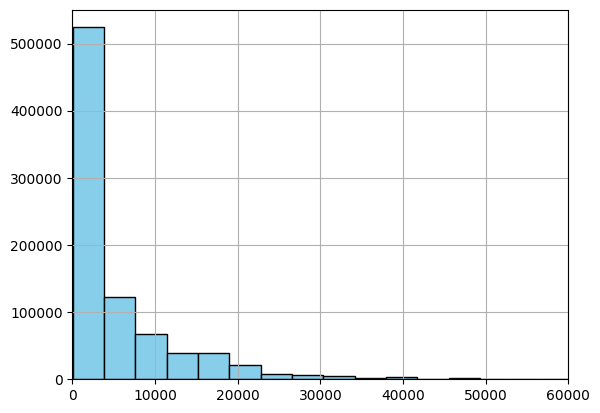

In [45]:
modeldata["CompetitionDistance"].hist(bins=20,color='skyblue', edgecolor='black')
plt.xlim(0,60000)
plt.show()

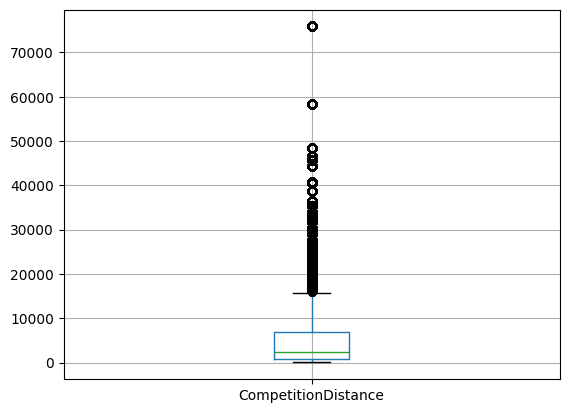

In [46]:
modeldata.boxplot(column="CompetitionDistance")
plt.show()

### CompetitionDistance has outliers and right skewed distribution so, we use median imputation

In [47]:
modeldata["CompetitionDistance"]=modeldata["CompetitionDistance"].fillna(
    modeldata["CompetitionDistance"].median()
)

In [48]:
modeldata["CompetitionDistance"].isna().sum()

np.int64(0)

In [49]:
modeldata.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2                            0
Promo2SinceWeek                   0
Promo2SinceYear                   0
PromoInterval                     0
dtype: int64

In [50]:
modeldata[
    modeldata["CompetitionOpenSinceMonth"].isna()
]["CompetitionDistance"].describe()

count    268619.000000
mean       5465.121380
std        7577.057022
min          20.000000
25%         620.000000
50%        2440.000000
75%        7890.000000
max       75860.000000
Name: CompetitionDistance, dtype: float64

In [51]:
modeldata[
    modeldata["CompetitionOpenSinceYear"].isna()
]["CompetitionDistance"].describe()

count    268619.000000
mean       5465.121380
std        7577.057022
min          20.000000
25%         620.000000
50%        2440.000000
75%        7890.000000
max       75860.000000
Name: CompetitionDistance, dtype: float64

In [52]:
modeldata[
    modeldata["CompetitionOpenSinceMonth"].isna()&
    modeldata["CompetitionOpenSinceYear"].isna()
].shape

(268619, 17)

### CompetitionOpenSinceMonth and CompetitionOpenSinceYear columns are missing together which means they depend on each other 
###   so, we use constant imputation of '0' 

In [53]:
modeldata["CompetitionOpenSinceMonth"]=modeldata["CompetitionOpenSinceMonth"].fillna(0)
modeldata["CompetitionOpenSinceYear"]=modeldata["CompetitionOpenSinceYear"].fillna(0)

In [54]:
modeldata.isna().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [55]:
modeldata["Sales"].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

In [56]:
modeldata["Customers"].describe()

count    844392.000000
mean        762.728395
std         401.227674
min           0.000000
25%         519.000000
50%         676.000000
75%         893.000000
max        7388.000000
Name: Customers, dtype: float64

In [57]:
modeldata["SchoolHoliday"].value_counts()

SchoolHoliday
0    680935
1    163457
Name: count, dtype: int64

In [58]:
modeldata["StateHoliday"].value_counts()

StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

* save the cleaned dataset

In [59]:
modeldata.to_csv(r'C:\Users\amikula pavani\jupyter-pycodes\mlproject\data\model_data.csv')